In [1]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'
import cv2
import numpy as np
import sys
import matplotlib.pyplot as plt

In [5]:
# --- 1. Definirea matricelor de conversie (Reinhard et al.) ---
# Sursa: "Color Transfer between Images", IEEE 2001

###############################################################################

_lms_from_rgb = np.array([
    [0.3811, 0.5783, 0.0402],
    [0.1967, 0.7244, 0.0782],
    [0.0241, 0.1288, 0.8444]
])

_rgb_from_lms = np.array([
    [4.4679, -3.5873, 0.1193],
    [-1.2186, 2.3809, -0.1624],
    [0.0497, -0.2439, 1.2045]
])

_lab_from_lms_coefs = np.array([
    [1/np.sqrt(3), 0, 0],
    [0, 1/np.sqrt(6), 0],
    [0, 0, 1/np.sqrt(2)]
])
_lab_from_lms_rot = np.array([
    [1, 1, 1],
    [1, 1, -2],
    [1, -1, 0]
])
_lab_from_lms = _lab_from_lms_coefs @ _lab_from_lms_rot

_lms_from_lab_coefs = np.array([
    [np.sqrt(3)/3, 0, 0],
    [0, np.sqrt(6)/6, 0],
    [0, 0, np.sqrt(2)/2]
])
_lms_from_lab_rot = np.array([
    [1, 1, 1],
    [1, 1, -1],
    [1, -2, 0]
])
_lms_from_lab = _lms_from_lab_rot @ _lms_from_lab_coefs

###############################################################################
# --- 2. Funcții de procesare a spațiului de culoare ---
###############################################################################

def rgb_to_lab(img):
    img_float = img / 255.0
    lms = np.dot(img_float, _lms_from_rgb.T)
    lms[lms < 1e-10] = 1e-10
    log_lms = np.log10(lms)
    lab = np.dot(log_lms, _lab_from_lms.T)
    return lab

def lab_to_rgb(lab):
    log_lms = np.dot(lab, _lms_from_lab.T)
    lms = np.power(10, log_lms)
    rgb = np.dot(lms, _rgb_from_lms.T)
    rgb = np.clip(rgb * 255.0, 0, 255).astype(np.uint8)
    return rgb

def get_stats_masked(lab_img, mask):
    """
    Calculează media și deviația standard doar pentru pixelii din mască.
    mask: imagine uint8 (H, W) unde zona selectată > 0
    """
    # Extragem pixelii care corespund măștii (boolean indexing)
    # Rezultatul este un array 1D de pixeli (N, 3)
    valid_pixels = lab_img[mask > 0]
    
    if len(valid_pixels) == 0:
        return np.zeros(3), np.ones(3) # Fallback dacă selecția e goală
        
    mean = np.mean(valid_pixels, axis=0)
    std = np.std(valid_pixels, axis=0)
    return mean, std

###############################################################################
# --- 3. Implementarea Swatches cu Măști ---
###############################################################################

def transfer_color_swatches_freehand(source_img, target_img, source_masks, target_masks):
    print("-> Se convertește imaginea în spațiul l-alpha-beta...")
    s_lab = rgb_to_lab(source_img)
    t_lab = rgb_to_lab(target_img)
    
    h, w, c = t_lab.shape
    
    # Acumulatori pentru blending
    blended_result = np.zeros_like(t_lab)
    total_weight = np.zeros((h, w, 1))
    
    num_swatches = min(len(source_masks), len(target_masks))
    if num_swatches == 0:
        print("Eroare: Nu au fost selectate regiuni.")
        return target_img

    print(f"-> Se procesează {num_swatches} perechi de swatches...")

    for i in range(num_swatches):
        # 1. Extrage statisticile folosind măștile desenate
        s_mean, s_std = get_stats_masked(s_lab, source_masks[i])
        t_mean, t_std = get_stats_masked(t_lab, target_masks[i])
        
        # Protecție la împărțirea cu zero
        s_std = np.clip(s_std, 1e-5, None)
        t_std = np.clip(t_std, 1e-5, None)

        print(f"  Cluster {i+1}: Calculare transfer...")
        
        # 2. Creează imaginea candidat (Eq. 11 - Reinhard)
        # Aplicăm transformarea statistică pe TOATĂ imaginea țintă
        scale = s_std / t_std
        candidate_img = (t_lab - t_mean) * scale + s_mean
        
        # 3. Calculează ponderile bazate pe distanță
        # (Pixelii care seamănă statistic cu clusterul țintă selectat vor primi greutate mai mare)
        diff = t_lab - t_mean
        
        # Distanța Euclidiană normalizată cu deviația standard
        norm_dist_sq = np.sum((diff / t_std) ** 2, axis=2)
        norm_dist = np.sqrt(norm_dist_sq)
        
        # Ponderare invers proporțională
        weight = 1.0 / (norm_dist + 1e-5)
        weight_map = weight[:, :, np.newaxis]
        
        # 4. Acumulare
        blended_result += candidate_img * weight_map
        total_weight += weight_map

    # 5. Normalizare finală
    print("Se combină rezultatele...")
    final_lab = blended_result / total_weight
    
    print("Conversie finală în RGB...")
    final_rgb = lab_to_rgb(final_lab)
    return final_rgb

###############################################################################
# --- 4. Interfața de selecție Liberă (Freehand) ---
###############################################################################

current_points = []
drawing = False
img_display = None
masks_list = [] # Lista care va ține măștile binare finale

def select_freehand_callback(event, x, y, flags, param):
    global current_points, drawing, img_display
    
    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
        current_points = [(x, y)]
        
    elif event == cv2.EVENT_MOUSEMOVE:
        if drawing:
            current_points.append((x, y))
            # Desenăm linia pe ecran pentru feedback vizual
            cv2.polylines(img_display, [np.array(current_points)], False, (0, 255, 0), 2)
            cv2.imshow("Selectare Libera", img_display)
            
    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False
        current_points.append((x, y))
        
        # Închidem poligonul vizual
        cv2.polylines(img_display, [np.array(current_points)], True, (0, 255, 0), 2)
        
        # Creăm masca binară pentru această selecție
        h, w = img_display.shape[:2]
        mask = np.zeros((h, w), dtype=np.uint8)
        cv2.fillPoly(mask, [np.array(current_points)], 255)
        
        masks_list.append(mask)
        cv2.imshow("Selectare Libera", img_display)
        print(f"   + Zona liberă adăugată (Total: {len(masks_list)})")

def get_user_masks_freehand(image, title="Imagine"):
    """
    Permite utilizatorului să deseneze forme libere. Returnează o listă de măști binare.
    """
    global masks_list, img_display, current_points
    masks_list = []
    current_points = []
    img_display = image.copy()
    
    cv2.namedWindow("Selectare Libera")
    cv2.setMouseCallback("Selectare Libera", select_freehand_callback)
    
    print(f"\n--- Selecție Liberă pentru {title} ---")
    print("   [Mouse Drag] -> Desenează conturul zonei dorite.")
    print("   [Release]    -> Închide forma automat.")
    print("   [ENTER]      -> CONFIRMĂ toate selecțiile și treci mai departe.")
    print("   [c]          -> ȘTERGE tot și ia-o de la capăt.")
    print("   [q/ESC]      -> IEȘIRE din program.")
    
    while True:
        cv2.imshow("Selectare Libera", img_display)
        k = cv2.waitKey(10) & 0xFF
        
        if k == 13: # Enter
            break
        elif k == ord('c'): # Clear
            masks_list = []
            img_display = image.copy()
            print("   ! Selecții șterse. Reîncepe.")
        elif k == ord('q') or k == 27: # Quit or ESC
            cv2.destroyAllWindows()
            return None
            
    cv2.destroyAllWindows()
    return masks_list

###############################################################################
# --- 5. MAIN EXECUTION ---
###############################################################################

if __name__ == "__main__":
    # Fișierele de intrare
    source_path = 'source_swatches.png' 
    target_path = 'target_swatches.png'
    
    src_img = cv2.imread(source_path)
    tgt_img = cv2.imread(target_path)
    
    if src_img is None or tgt_img is None:
        print("Eroare: Imaginile nu au fost găsite.")
        sys.exit()

    # --- PASUL 1: SELECȚIA SURSĂ (FREEHAND) ---
    print("PASUL 1: Desenează zonele pe imaginea SURSĂ (ex: conturul cerului)")
    src_masks = get_user_masks_freehand(src_img, "Sursa")
    
    if src_masks is None:
        print("\n[Ieșire forțată.]")
        sys.exit()
        
    # --- PASUL 2: SELECȚIA ȚINTĂ (FREEHAND) ---
    print(f"PASUL 2: Desenează zonele corespondente pe imaginea ȚINTĂ")
    tgt_masks = get_user_masks_freehand(tgt_img, "Tinta")

    if tgt_masks is None:
        print("\n[Ieșire forțată.]")
        sys.exit()
    
    # Validare perechi
    if len(src_masks) != len(tgt_masks):
        n = min(len(src_masks), len(tgt_masks))
        print(f"Atenție: Număr inegal de selecții. Se vor folosi primele {n} perechi.")
    
    # --- PASUL 3: PROCESAREA ---
    # Acum trimitem măștile, nu coordonatele
    result = transfer_color_swatches_freehand(src_img, tgt_img, src_masks, tgt_masks)
    
    # --- PASUL 4: REZULTAT FINAL ---
    print("\n--- Gata! ---")
    print("   [s]     -> Salvează 'rezultat_swatches.png'")
    print("   [q/ESC] -> Ieșire")
    
    cv2.imshow('Sursa', src_img)
    cv2.imshow('Tinta Originala', tgt_img)
    cv2.imshow('Rezultat Transfer Swatches', result)

    while True:
        k = cv2.waitKey(10) & 0xFF

        if k == ord('s'):
            cv2.imwrite('rezultat_swatches.png', result)
            print("-> Imagine salvată!")
        
        elif k == ord('q') or k == 27:
            print("-> La revedere!")
            break
            
    cv2.destroyAllWindows()

PASUL 1: Desenează zonele pe imaginea SURSĂ (ex: conturul cerului)

--- Selecție Liberă pentru Sursa ---
   [Mouse Drag] -> Desenează conturul zonei dorite.
   [Release]    -> Închide forma automat.
   [ENTER]      -> CONFIRMĂ toate selecțiile și treci mai departe.
   [c]          -> ȘTERGE tot și ia-o de la capăt.
   [q/ESC]      -> IEȘIRE din program.
   + Zona liberă adăugată (Total: 1)
   + Zona liberă adăugată (Total: 2)
PASUL 2: Desenează zonele corespondente pe imaginea ȚINTĂ

--- Selecție Liberă pentru Tinta ---
   [Mouse Drag] -> Desenează conturul zonei dorite.
   [Release]    -> Închide forma automat.
   [ENTER]      -> CONFIRMĂ toate selecțiile și treci mai departe.
   [c]          -> ȘTERGE tot și ia-o de la capăt.
   [q/ESC]      -> IEȘIRE din program.
   + Zona liberă adăugată (Total: 1)
   + Zona liberă adăugată (Total: 2)
-> Se convertește imaginea în spațiul l-alpha-beta...
-> Se procesează 2 perechi de swatches...
  Cluster 1: Calculare transfer...
  Cluster 2: Calcu

In [ ]:
# Afisarea imaginilor sursa, tinta si rezultat corespunzatoarea fiecarei perechi side-by-side dupa apasarea tastei Enter la final
# Afisare cu plt si mesaje
def display_images():
    src_img = cv2.imread('source_swatches.png')
    tgt_img = cv2.imread('target_swatches.png')
    result_img = cv2.imread('rezultat_swatches.png')

    if src_img is None or tgt_img is None or result_img is None:
        print("Eroare: Una sau mai multe imagini nu au fost găsite.")
        return

    # Convertim BGR la RGB pentru afișare corectă
    src_img_rgb = cv2.cvtColor(src_img, cv2.COLOR_BGR2RGB)
    tgt_img_rgb = cv2.cvtColor(tgt_img, cv2.COLOR_BGR2RGB)
    result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(tgt_img_rgb)
    axs[0].set_title('Imagine Sursă')
    axs[0].axis('off')

    axs[1].imshow(src_img_rgb)
    axs[1].set_title('Imagine Țintă')
    axs[1].axis('off')

    axs[2].imshow(result_img_rgb)
    axs[2].set_title('Rezultat Transfer Swatches')
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()



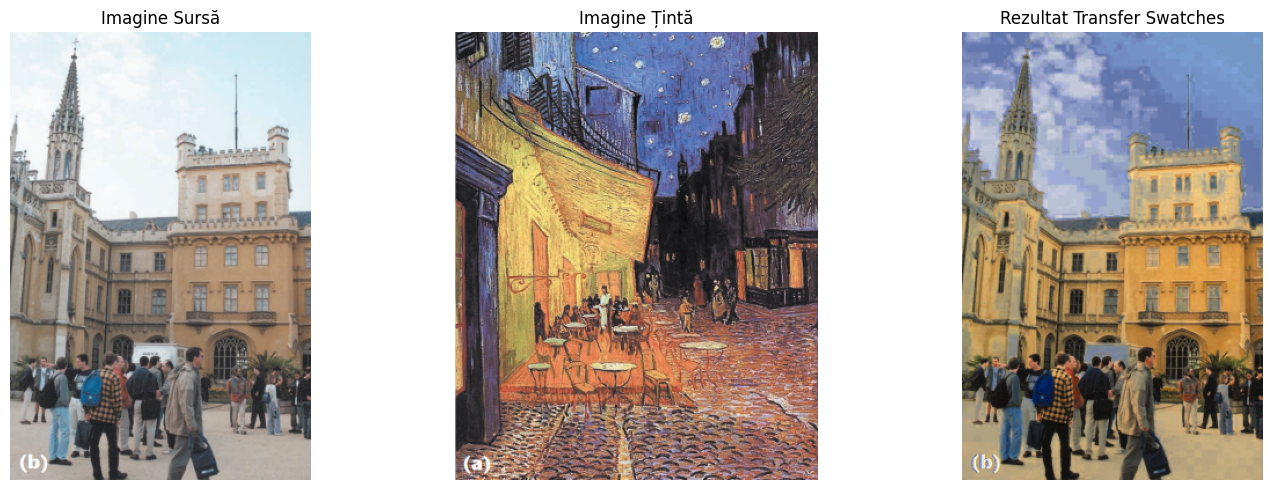

In [39]:
if __name__ == "__main__":
    display_images()

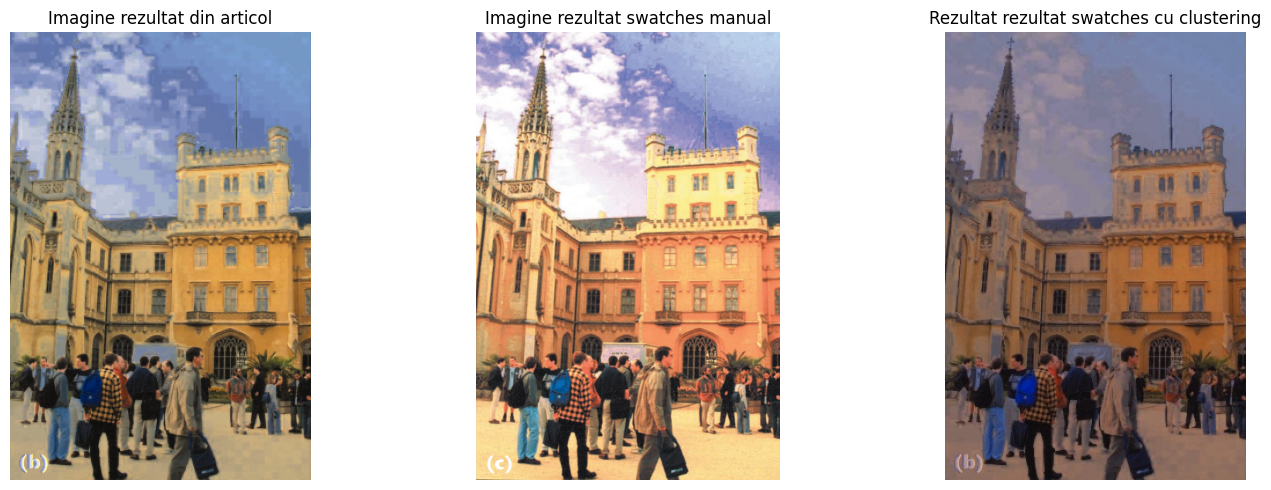

In [59]:
# Show side-by-side rezultat_swatches_articol, rezultat_swatches, rezultat_cluster_v3
def display_images():
    src_img = cv2.imread('rezultat_swatches_articol.png')
    tgt_img = cv2.imread('rezultat_swatches.png')
    result_img = cv2.imread('rezultat_cluster_v3.jpg')

    if src_img is None or tgt_img is None or result_img is None:
        print("Eroare: Una sau mai multe imagini nu au fost găsite.")
        return

    # Convertim BGR la RGB pentru afișare corectă
    src_img_rgb = cv2.cvtColor(src_img, cv2.COLOR_BGR2RGB)
    tgt_img_rgb = cv2.cvtColor(tgt_img, cv2.COLOR_BGR2RGB)
    result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(tgt_img_rgb)
    axs[0].set_title('Imagine rezultat din articol')
    axs[0].axis('off')

    axs[1].imshow(src_img_rgb)
    axs[1].set_title('Imagine rezultat swatches manual')
    axs[1].axis('off')

    axs[2].imshow(result_img_rgb)
    axs[2].set_title('Rezultat rezultat swatches cu clustering')
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    display_images()